In [1]:
!pip install lightgbm

In [2]:
!pip install category_encoders

In [3]:
import os
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
from contextlib import contextmanager
from time import time
from tqdm import tqdm
import lightgbm as lgbm
import category_encoders as ce
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, log_loss, accuracy_score
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold
from imblearn.over_sampling import SMOTE


In [4]:
# 'imbalanced-learn' 패키지를 설치해야 합니다.
!pip install imbalanced-learn

In [5]:
data0 = pd.read_csv("원재료입고(260301).csv", engine = 'python', encoding = 'CP949')
data0

,원재료입고_ID,입고일,원재료명,입고거래처(매입처),전화,담당자,용도,투입공정,입고검사,생산투입수량,단가,적정재고,입고수량,적정재고 여부,입고금,부가세,총금액,세금계산서발급
0,59038df8,2025-05-01,46049545,9f74bd18,537451345,도라지,조임용,배합,"스크래치 , 반품대기",200,4,"1,000","3,500,000",적정,"14,000,000","1,400,000","15,400,000",False
1,fd0c7d5a,2025-05-09,c541ea47,3b549df4,638634512,이도령,소비자 보호용,조립 1공정,"유통기한경과 , 반품대기",4000,"30,000",10,15,적정,"450,000","45,000","495,000",True
2,fcc8d102,2025-02-11,jghd45fh,b5bdcf0b,25627485,채송화,나사못 박기,사상,"외관불량 , 유통기한경과 , 반품대기",150,20,"20,000","50,000",적정,"1,000,000","100,000","1,100,000",True
3,4bda3a3b,2025-05-23,46049545,9f74bd18,537451345,도라지,조임용,배합,"유통기한경과 , 품질이상",500,4,"40,000","890,000",적정,"3,560,000","356,000","3,916,000",False
4,8247090b,2025-05-01,46049545,9f74bd18,537451345,도라지,조임용,배합,"표기사항이상 , 반품대기",200,4,200,"1,560,000",적정,"6,240,000","624,000","6,864,000",True
5,c832b388,2025-05-27,23f246df,39bf8450,104527485,저산하,풀리 제거용,사상,"품질이상 , 반품대기",500,"56,000",200,50,적정,"2,800,000","280,000","3,080,000",True
6,8012ebd4,2025-06-06,4f440cfd,39bf8450,104527485,저산하,이산화탄소 용해,배합,유통기한경과,500,"5,000","5,000",450,적정,"2,250,000","225,000","2,475,000",True
7,7a67fa3a,2024-06-11,hfgfh67f,678de4nd,107457485,이세돌,지지대용,성형,"외관불량 , 유통기한경과",4000,"50,000","1,000","50,000",적정,"2,500,000,000","250,000,000","2,750,000,000",True
8,9d8abaa0,2024-01-08,ea924da6,207fecd0,033 451 3654,남대천,철판 가공용,밀링,"외관불량 , 품질이상 , 반품대기",5000,"40,000","1,200",400,적정,"16,000,000","1,600,000","17,600,000",False
9,20553bc4,2024-02-26,2c732888,4fd0a372,02 1755 3543,예성강,행잉,포장,"스크래치 , 외관불량",500,"35,000","23,000",350,적정,"12,250,000","1,225,000","13,475,000",False


In [6]:
from sklearn.preprocessing import LabelEncoder

def labelencoder(df):
    for c in df.columns:
        if df[c].dtype=='object': 
            df[c] = df[c].fillna('N')
            lbl = LabelEncoder()
            lbl.fit(list(df[c].values))
            df[c] = lbl.transform(df[c].values)
    return df

    df

In [7]:
data1=labelencoder(data0.iloc[:,1:])

In [8]:
target=['원재료명','담당자','용도']
dataY=data1[target]
dataX=data1.drop(target,axis=1)

In [9]:
df_columns = list(dataX.columns)
print(df_columns)

['입고일', '입고거래처(매입처)', '전화', '투입공정', '입고검사', '생산투입수량', '단가', '적정재고', '입고수량', '적정재고 여부', '입고금', '부가세', '총금액', '세금계산서발급']


In [10]:
m=len(dataX)
print(m)
M=list(range(m))
random.seed(2021)
random.shuffle(M)

trainX=dataX.iloc[M[0:(m//4)*3]]
trainY=dataY.iloc[M[0:(m//4)*3]]
testX=dataX.iloc[M[(m//4)*3:]]
testY=dataY.iloc[M[(m//4)*3:]]

32


In [11]:
from sklearn.model_selection import train_test_split

trainX, testX, trainY, testY = train_test_split(
    dataX, dataY, test_size=0.25, random_state=2021
)

In [12]:
train_df=trainX
test_df=testX

In [13]:
train_df.columns=df_columns
test_df.columns=df_columns

def create_numeric_feature(input_df):
    use_columns = df_columns 
    return input_df[use_columns].copy()

In [14]:
from contextlib import contextmanager
from time import time

class Timer:
    def __init__(self, logger=None, format_str='{:.3f}[s]', prefix=None, suffix=None, sep=' '):

        if prefix: format_str = str(prefix) + sep + format_str
        if suffix: format_str = format_str + sep + str(suffix)
        self.format_str = format_str
        self.logger = logger
        self.start = None
        self.end = None

    @property
    def duration(self):


        if self.end is None:
            return 0
        return self.end - self.start

    def __enter__(self):
        self.start = time()

    def __exit__(self, exc_type, exc_val, exc_tb):
        self.end = time()
        out_str = self.format_str.format(self.duration)
        if self.logger:
            self.logger.info(out_str)
        else:
            print(out_str)

In [15]:
from tqdm import tqdm

def to_feature(input_df):

    processors = [
        create_numeric_feature,
    ]
    
    out_df = pd.DataFrame()
    
    for func in tqdm(processors, total=len(processors)):
        with Timer(prefix='create' + func.__name__ + ' '):
            _df = func(input_df)

        assert len(_df) == len(input_df), func.__name__


        out_df = pd.concat([out_df, _df], axis=1)
        
    return out_df

In [16]:
train_feat_df = to_feature(train_df)
test_feat_df = to_feature(test_df)

100%|███████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 328.55it/s]


createcreate_numeric_feature  0.002[s]


100%|███████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 294.63it/s]

createcreate_numeric_feature  0.002[s]


In [17]:
from lightgbm import early_stopping, log_evaluation

def fit_lgbm(X, y, cv, params, verbose):
    import numpy as np
    import lightgbm as lgbm
    
    models = []
    oof_pred = np.zeros_like(y, dtype=float) # 이전에 고친 float 반영

    for i, (idx_train, idx_valid) in enumerate(cv):
        x_train, y_train = X[idx_train], y[idx_train]
        x_valid, y_valid = X[idx_valid], y[idx_valid]

        clf = lgbm.LGBMRegressor(**params)

        # 수정된 fit 부분
        clf.fit(x_train, y_train, 
                eval_set=[(x_valid, y_valid)],
                callbacks=[
                    early_stopping(stopping_rounds=100),
                    log_evaluation(period=verbose)
                ])

        pred_i = clf.predict(x_valid)
        oof_pred[idx_valid] = pred_i
        models.append(clf)

    return oof_pred, models

In [18]:
params = {
    'objective': 'rmse', 
    'learning_rate': .1,
    'reg_lambda': 1.,
    'reg_alpha': .1,
    'max_depth': 5, 
    'n_estimators': 10000, 
    'colsample_bytree': .5, 
    'min_child_samples': 10,
    'subsample_freq': 3,
    'subsample': .9,
    'importance_type': 'gain', 
    'random_state': 71,
    'num_leaves': 48
}

In [19]:
y = trainY
ydf=pd.DataFrame(y)
ydf[0:5]

,원재료명,담당자,용도
28,13,5,14
2,17,11,1
10,6,0,0
17,11,8,4
23,7,9,15


[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 19, number of used features: 0
[LightGBM] [Info] Start training from score 9.736842
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stoppe

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\USER\AppData\Local\Temp\ipykernel_17244\502493813.py:46: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_17244\502493813.py:46: UserWarning: Glyph 51116 (\N{HANGUL SYLLABLE JAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_17244\502493813.py:46: UserWarning: Glyph 47308 (\N{HANGUL SYLLABLE RYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_17244\502493813.py:46: UserWarning: Glyph 47749 (\N{HANGUL SYLLABLE MYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50896 (\N{HANGUL SYLLABL

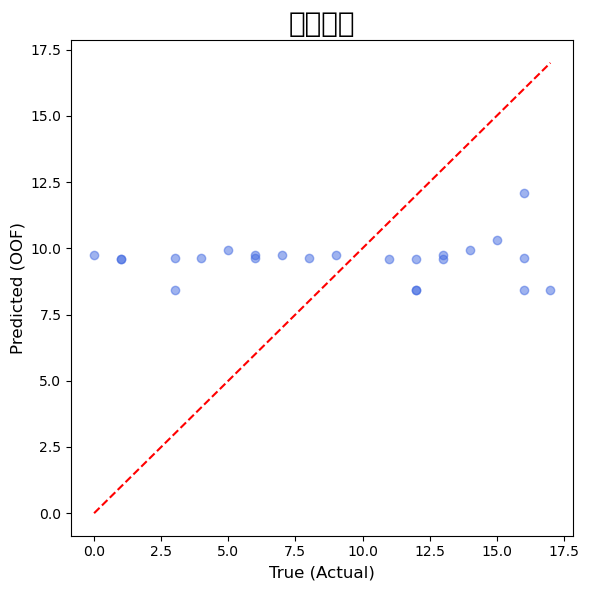

[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 19, number of used features: 0
[LightGBM] [Info] Start training from score 6.473684
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stoppe

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\USER\AppData\Local\Temp\ipykernel_17244\502493813.py:46: UserWarning: Glyph 45812 (\N{HANGUL SYLLABLE DAM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_17244\502493813.py:46: UserWarning: Glyph 45817 (\N{HANGUL SYLLABLE DANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_17244\502493813.py:46: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 45812 (\N{HANGUL SYLLABLE DAM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph

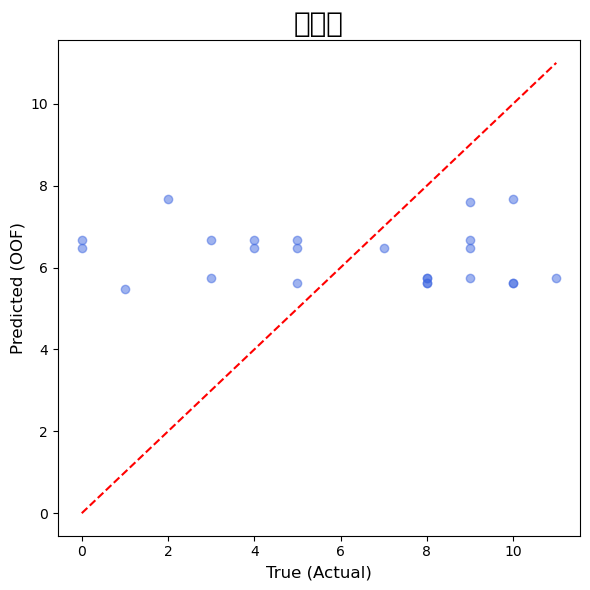

[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 19, number of used features: 0
[LightGBM] [Info] Start training from score 7.578947
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stoppe

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\USER\AppData\Local\Temp\ipykernel_17

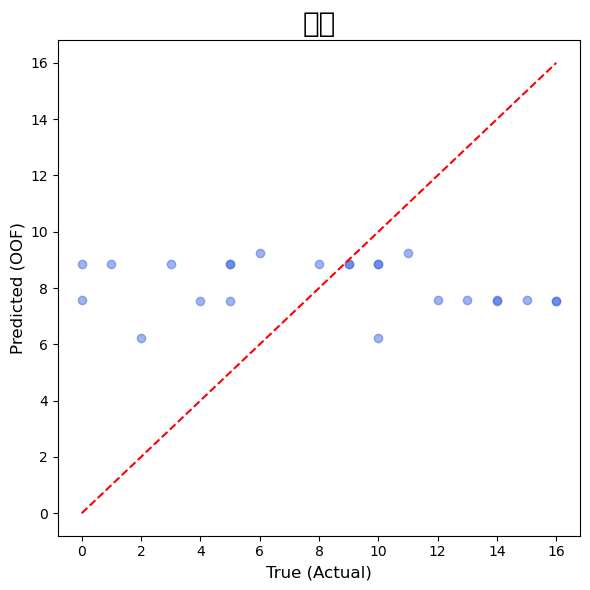

In [20]:
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt
import numpy as np

# 결과 저장을 위한 리스트
MODEL = []
OOF = []

# 3개의 타겟 변수에 대해 반복 (예: target[0], target[1], target[2])
for i in range(3):
    # 1. K-Fold 설정 (5개로 나누어 교차 검증)
    fold = KFold(n_splits=5, shuffle=True, random_state=71)
    
    # 2. i번째 타겟 데이터 준비
    ydfi = ydf.iloc[:, i]
    y = np.array(ydfi)
    
    # 3. 교차 검증용 인덱스 생성
    cv = list(fold.split(train_feat_df, y))
    
    # 4. 모델 학습 (fit_lgbm 내부의 np.float 에러가 해결된 상태여야 함)
    # verbose 인자는 LightGBM 버전에 따라 'log_evaluation' 등으로 대체될 수 있습니다.
    oof, models = fit_lgbm(train_feat_df.values, y, cv, params=params, verbose=500)
    
    # 5. 결과 저장
    MODEL.append(models)
    OOF.append(oof)
    
    # 6. 시각화 (실제값 vs 예측값 산점도)
    fig, ax = plt.subplots(figsize=(6, 6))
    
    # target 리스트가 정의되어 있다고 가정합니다.
    title_name = target[i] if 'target' in locals() else f"Target {i}"
    ax.set_title(title_name, fontsize=20)
    
    ax.set_ylabel('Predicted (OOF)', fontsize=12)
    ax.set_xlabel('True (Actual)', fontsize=12)
    
    # 산점도 그리기
    ax.scatter(y, oof, alpha=0.5, color='royalblue')
    
    # 완벽한 예측을 의미하는 대각선(y=x) 추가 (분석에 도움됨)
    line = np.linspace(min(y), max(y), 100)
    ax.plot(line, line, color='red', linestyle='--')
    
    plt.tight_layout()
    plt.show() # 반복문 안에서 각 그래프를 즉시 출력합니다.

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 16, number of used features: 0
[LightGBM] [Info] Start training from score 10.437500
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopp

C:\Users\USER\AppData\Local\Temp\ipykernel_17244\3909848820.py:34: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_17244\3909848820.py:34: UserWarning: Glyph 51116 (\N{HANGUL SYLLABLE JAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_17244\3909848820.py:34: UserWarning: Glyph 47308 (\N{HANGUL SYLLABLE RYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_17244\3909848820.py:34: UserWarning: Glyph 47749 (\N{HANGUL SYLLABLE MYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51116 (\N

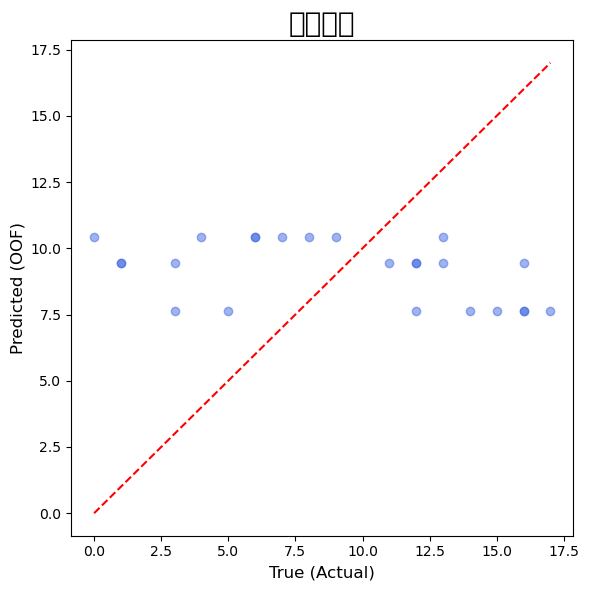

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\USER\AppData\Local\Temp\ipykernel_17244\3909848820.py:34: UserWarning: Glyph 45812 (\N{HANGUL SYLLABLE DAM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_17244\3909848820.py:34: UserWarning: Glyph 45817 (\N{HANGUL SYLLABLE DANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_17244\3909848820.py:34: UserWarning: 

[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 16, number of used features: 0
[LightGBM] [Info] Start training from score 7.125000
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stoppe

C:\Users\USER\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 45812 (\N{HANGUL SYLLABLE DAM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 45817 (\N{HANGUL SYLLABLE DANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


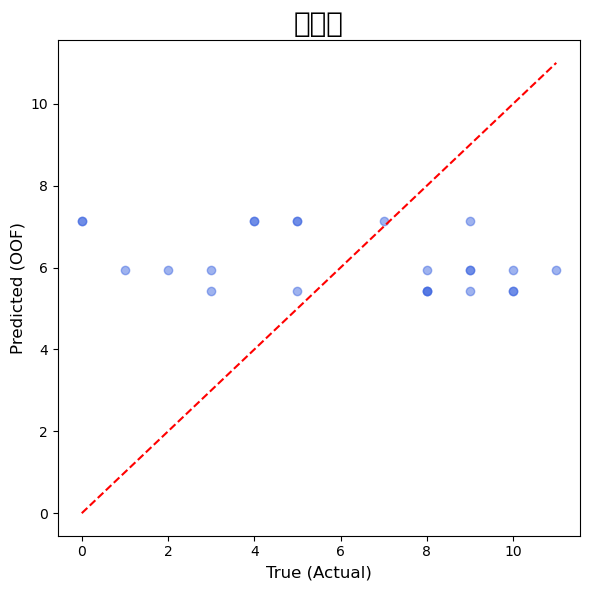

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 16, number of used features: 0
[LightGBM] [Info] Start training from score 8.312500
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stoppe

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\USER\AppData\Local\Temp\ipykernel_17244\3909848820.py:34: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_17244\3909848820.py:34: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:1

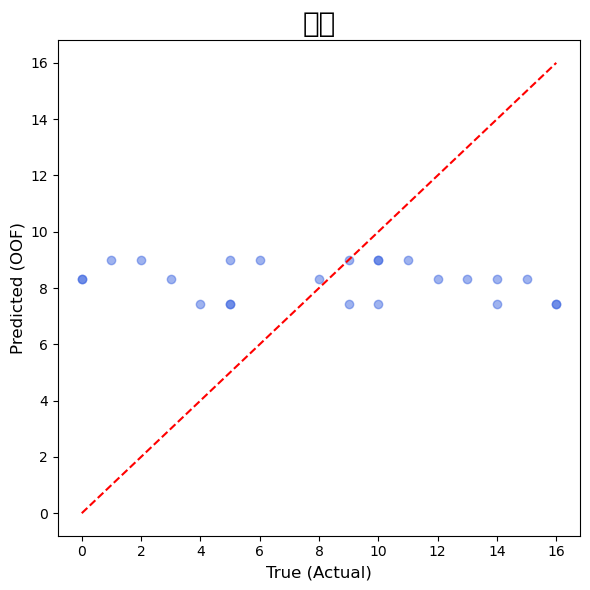

In [21]:
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt
import numpy as np

MODEL = []
OOF = []

for i in range(3):
    fold = KFold(n_splits=3, shuffle=True, random_state=71)  # 5 → 3으로 축소 (데이터 24개 대응)
    
    ydfi = ydf.iloc[:, i]
    y = np.array(ydfi)
    
    cv = list(fold.split(train_feat_df, y))
    
    oof, models = fit_lgbm(train_feat_df.values, y, cv, params=params, verbose=500)
    
    MODEL.append(models)
    OOF.append(oof)
    
    fig, ax = plt.subplots(figsize=(6, 6))
    
    title_name = ydf.columns[i]   # target[i] 대신 실제 열 이름 사용
    ax.set_title(title_name, fontsize=20)
    
    ax.set_ylabel('Predicted (OOF)', fontsize=12)
    ax.set_xlabel('True (Actual)', fontsize=12)
    
    ax.scatter(y, oof, alpha=0.5, color='royalblue')
    
    line = np.linspace(min(y), max(y), 100)
    ax.plot(line, line, color='red', linestyle='--')
    
    plt.tight_layout()
    plt.show()

In [22]:
import seaborn as sns

def visualize_importance(models, feat_train_df):

    feature_importance_df = pd.DataFrame()
    for i, model in enumerate(models):
        _df = pd.DataFrame()
        _df['feature_importance'] = model.feature_importances_
        _df['column'] = feat_train_df.columns
        _df['fold'] = i + 1
        feature_importance_df = pd.concat([feature_importance_df, _df], 
                                          axis=0, ignore_index=True)

    order = feature_importance_df.groupby('column')\
        .sum()[['feature_importance']]\
        .sort_values('feature_importance', ascending=False).index[:50]

    fig, ax = plt.subplots(figsize=(8, max(6, len(order) * .25)))


    sns.boxenplot(data=feature_importance_df, 
                  x='feature_importance', 
                  y='column', 
                  order=order, 
                  ax=ax, 
                  palette='viridis', 
                  orient='h')
    
    ax.tick_params(axis='x', rotation=0)
    #ax.set_title('Importance')
    ax.grid()
    fig.tight_layout()
    
    return fig,ax


C:\Users\USER\AppData\Local\Temp\ipykernel_17244\4105085207.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=feature_importance_df,
C:\Users\USER\AppData\Local\Temp\ipykernel_17244\4105085207.py:32: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_17244\4105085207.py:32: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_17244\4105085207.py:32: UserWarning: Glyph 48512 (\N{HANGUL SYLLABLE BU}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_17244\4105085207.py:32: UserWarning: Glyph 49464 (\N{HANGUL SYLLABLE SE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\USER\App

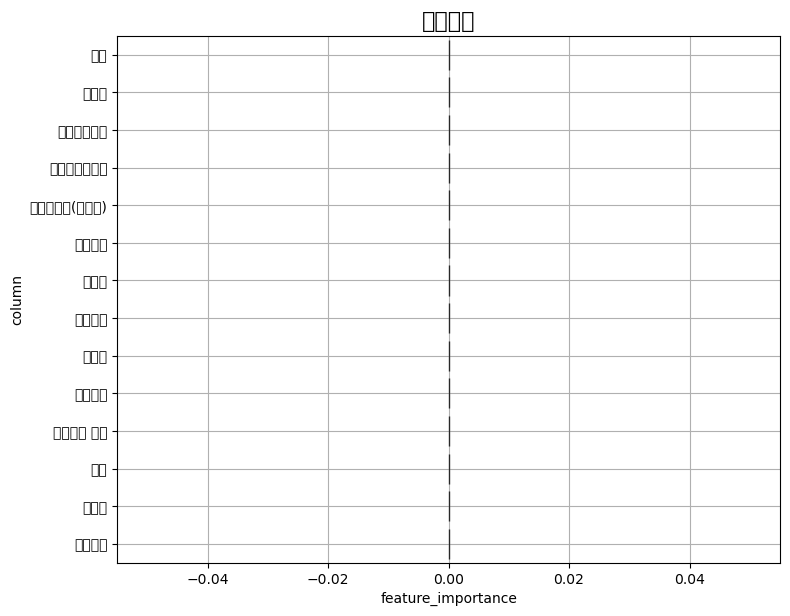

C:\Users\USER\AppData\Local\Temp\ipykernel_17244\4105085207.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=feature_importance_df,
C:\Users\USER\AppData\Local\Temp\ipykernel_17244\4105085207.py:32: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_17244\4105085207.py:32: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_17244\4105085207.py:32: UserWarning: Glyph 48512 (\N{HANGUL SYLLABLE BU}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_17244\4105085207.py:32: UserWarning: Glyph 49464 (\N{HANGUL SYLLABLE SE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\USER\App

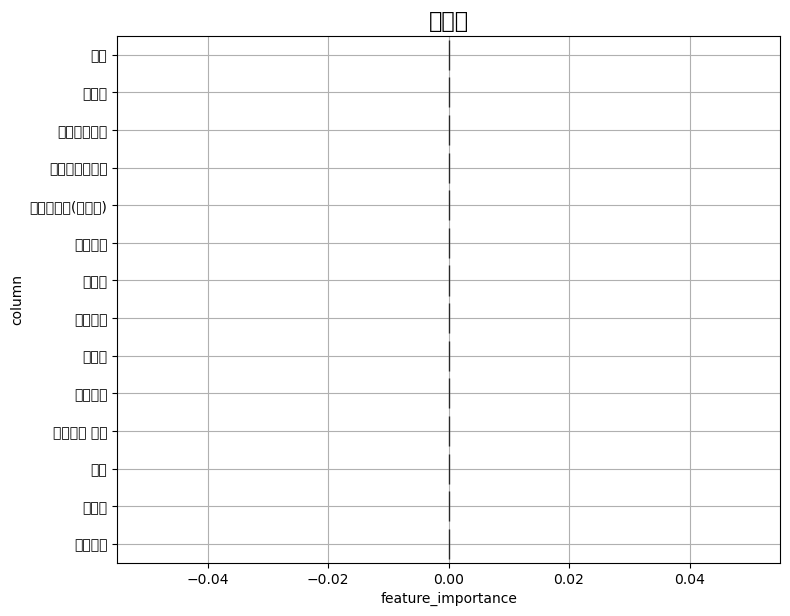

C:\Users\USER\AppData\Local\Temp\ipykernel_17244\4105085207.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=feature_importance_df,
C:\Users\USER\AppData\Local\Temp\ipykernel_17244\4105085207.py:32: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_17244\4105085207.py:32: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_17244\4105085207.py:32: UserWarning: Glyph 48512 (\N{HANGUL SYLLABLE BU}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_17244\4105085207.py:32: UserWarning: Glyph 49464 (\N{HANGUL SYLLABLE SE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\USER\App

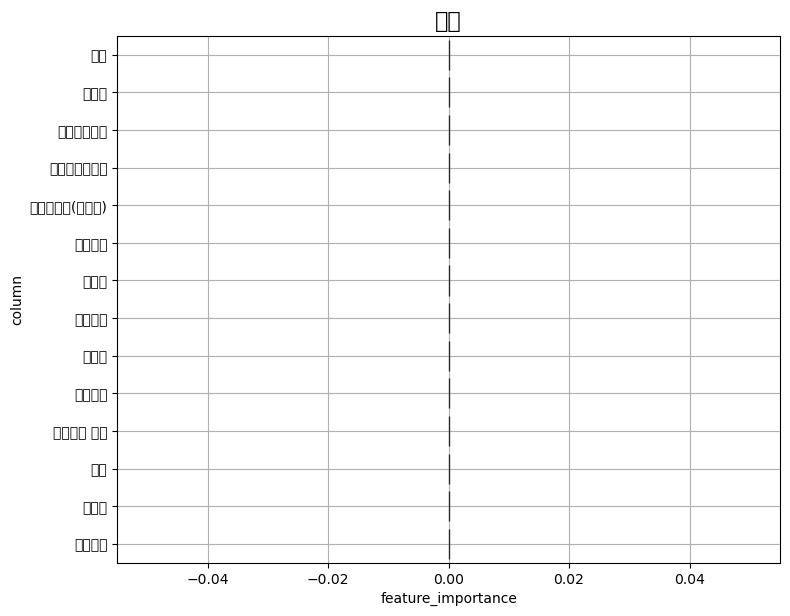

In [23]:
for i in range(3):
    fig, ax = visualize_importance(MODEL[i], train_feat_df)
    ax.set_title(ydf.columns[i], fontsize=16)
    plt.show()   # 명시적으로 화면에 표시

In [24]:
print(len(MODEL))           # 3이 나와야 정상 (타겟 3개)
for i in range(len(MODEL)):
    print(f"MODEL[{i}] 개수:", len(MODEL[i]))   # fold 개수만큼 나와야 함

3
MODEL[0] 개수: 3
MODEL[1] 개수: 3
MODEL[2] 개수: 3


In [25]:
models = MODEL[0]
feat_train_df = train_feat_df

feature_importance_df = pd.DataFrame()
for i, model in enumerate(models):
    _df = pd.DataFrame()
    _df['feature_importance'] = model.feature_importances_
    _df['column'] = feat_train_df.columns
    _df['fold'] = i + 1
    feature_importance_df = pd.concat([feature_importance_df, _df], axis=0, ignore_index=True)

print(feature_importance_df)   # 여기서 값이 제대로 찍히는지 확인
print(feature_importance_df.shape)

    feature_importance      column  fold
0                  0.0         입고일     1
1                  0.0  입고거래처(매입처)     1
2                  0.0          전화     1
3                  0.0        투입공정     1
4                  0.0        입고검사     1
5                  0.0      생산투입수량     1
6                  0.0          단가     1
7                  0.0        적정재고     1
8                  0.0        입고수량     1
9                  0.0     적정재고 여부     1
10                 0.0         입고금     1
11                 0.0         부가세     1
12                 0.0         총금액     1
13                 0.0     세금계산서발급     1
14                 0.0         입고일     2
15                 0.0  입고거래처(매입처)     2
16                 0.0          전화     2
17                 0.0        투입공정     2
18                 0.0        입고검사     2
19                 0.0      생산투입수량     2
20                 0.0          단가     2
21                 0.0        적정재고     2
22                 0.0        입고수량     2
23              

In [26]:
print(len(MODEL))
for i in range(len(MODEL)):
    print(f"MODEL[{i}] 개수:", len(MODEL[i]))

3
MODEL[0] 개수: 3
MODEL[1] 개수: 3
MODEL[2] 개수: 3


C:\Users\USER\AppData\Local\Temp\ipykernel_17244\4105085207.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=feature_importance_df,
C:\Users\USER\AppData\Local\Temp\ipykernel_17244\4105085207.py:32: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_17244\4105085207.py:32: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_17244\4105085207.py:32: UserWarning: Glyph 48512 (\N{HANGUL SYLLABLE BU}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_17244\4105085207.py:32: UserWarning: Glyph 49464 (\N{HANGUL SYLLABLE SE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\USER\App

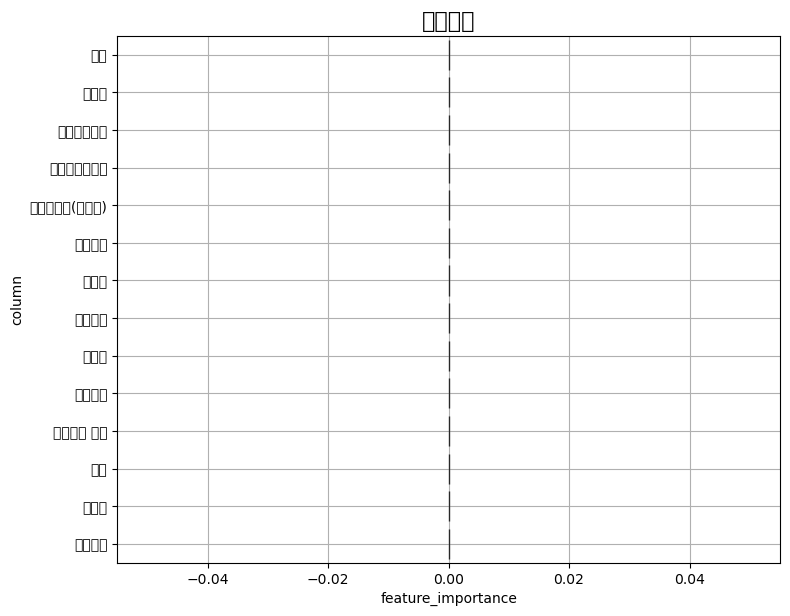

C:\Users\USER\AppData\Local\Temp\ipykernel_17244\4105085207.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=feature_importance_df,
C:\Users\USER\AppData\Local\Temp\ipykernel_17244\4105085207.py:32: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_17244\4105085207.py:32: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_17244\4105085207.py:32: UserWarning: Glyph 48512 (\N{HANGUL SYLLABLE BU}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_17244\4105085207.py:32: UserWarning: Glyph 49464 (\N{HANGUL SYLLABLE SE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\USER\App

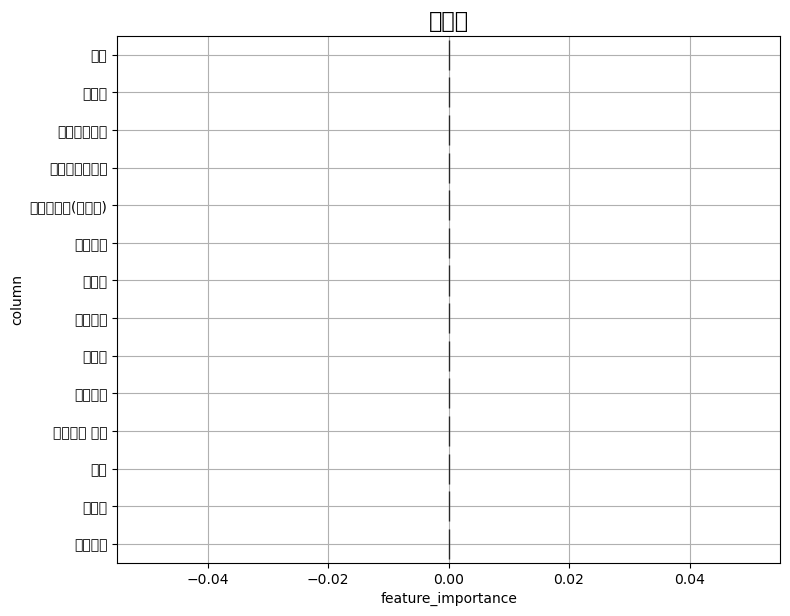

C:\Users\USER\AppData\Local\Temp\ipykernel_17244\4105085207.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=feature_importance_df,
C:\Users\USER\AppData\Local\Temp\ipykernel_17244\4105085207.py:32: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_17244\4105085207.py:32: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_17244\4105085207.py:32: UserWarning: Glyph 48512 (\N{HANGUL SYLLABLE BU}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_17244\4105085207.py:32: UserWarning: Glyph 49464 (\N{HANGUL SYLLABLE SE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\USER\App

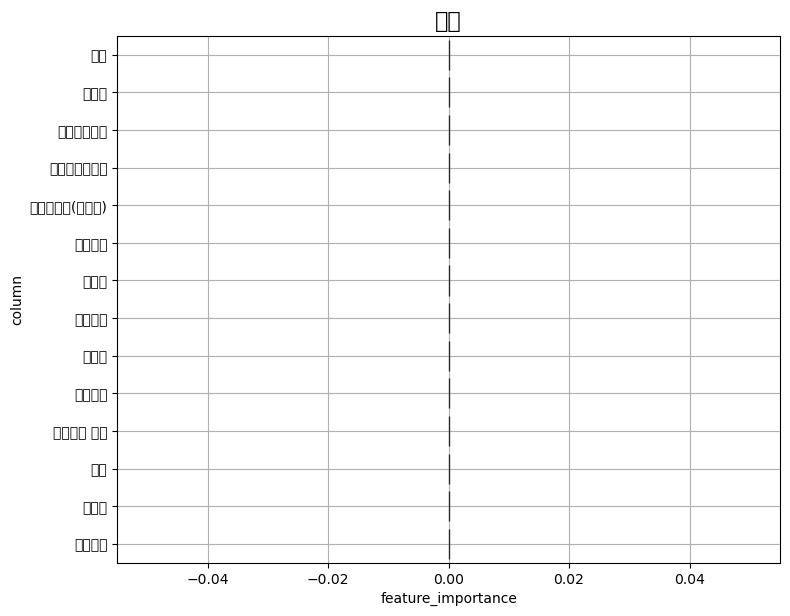

In [27]:
for i in range(len(MODEL)):
    fig, ax = visualize_importance(MODEL[i], train_feat_df)
    ax.set_title(ydf.columns[i], fontsize=16)
    plt.show()

In [28]:
print(len(MODEL))
for i in range(len(MODEL)):
    print(f"MODEL[{i}] 개수:", len(MODEL[i]))

3
MODEL[0] 개수: 3
MODEL[1] 개수: 3
MODEL[2] 개수: 3


In [29]:
models = MODEL[0]
feat_train_df = train_feat_df

feature_importance_df = pd.DataFrame()
for i, model in enumerate(models):
    _df = pd.DataFrame()
    _df['feature_importance'] = model.feature_importances_
    _df['column'] = feat_train_df.columns
    _df['fold'] = i + 1
    feature_importance_df = pd.concat([feature_importance_df, _df], axis=0, ignore_index=True)

print(feature_importance_df)
print(feature_importance_df.shape)

    feature_importance      column  fold
0                  0.0         입고일     1
1                  0.0  입고거래처(매입처)     1
2                  0.0          전화     1
3                  0.0        투입공정     1
4                  0.0        입고검사     1
5                  0.0      생산투입수량     1
6                  0.0          단가     1
7                  0.0        적정재고     1
8                  0.0        입고수량     1
9                  0.0     적정재고 여부     1
10                 0.0         입고금     1
11                 0.0         부가세     1
12                 0.0         총금액     1
13                 0.0     세금계산서발급     1
14                 0.0         입고일     2
15                 0.0  입고거래처(매입처)     2
16                 0.0          전화     2
17                 0.0        투입공정     2
18                 0.0        입고검사     2
19                 0.0      생산투입수량     2
20                 0.0          단가     2
21                 0.0        적정재고     2
22                 0.0        입고수량     2
23              

In [30]:
model = MODEL[0][0]   # 원재료명 타겟, 1번째 폴드 모델
print("트리 개수:", model.n_estimators_)
print("best_iteration:", model.best_iteration_)

트리 개수: 1
best_iteration: 1


In [31]:
params = {
    'objective': 'rmse',
    'learning_rate': 0.05,
    'reg_lambda': 1.,
    'reg_alpha': 0.1,
    'max_depth': 3,
    'n_estimators': 10000,
    'colsample_bytree': 0.8,
    'min_child_samples': 2,      # 10 → 2로 대폭 축소 (핵심)
    'subsample_freq': 1,
    'subsample': 0.9,
    'importance_type': 'gain',
    'random_state': 71,
    'num_leaves': 7               # 62 → 7로 축소 (핵심)
}

In [32]:
early_stopping(stopping_rounds=20)

In [33]:
# 1. params 위처럼 수정
# 2. fit_lgbm 함수의 stopping_rounds=100 → 20으로 수정
# 3. 학습 다시 실행
MODEL = []
OOF = []
for i in range(3):
    fold = KFold(n_splits=3, shuffle=True, random_state=71)
    y = np.array(ydf.iloc[:, i])
    cv = list(fold.split(train_feat_df, y))
    oof, models = fit_lgbm(train_feat_df.values, y, cv, params=params, verbose=500)
    MODEL.append(models)
    OOF.append(oof)

# 4. 중요도 다시 확인
model = MODEL[0][0]
print("best_iteration:", model.best_iteration_)
print("importances:", model.feature_importances_)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000332 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 74
[LightGBM] [Info] Number of data points in the train set: 16, number of used features: 13
[LightGBM] [Info] Start training from score 10.437500
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] 

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\skl

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


C:\Users\USER\AppData\Local\Temp\ipykernel_17244\4105085207.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=feature_importance_df,
C:\Users\USER\AppData\Local\Temp\ipykernel_17244\4105085207.py:32: UserWarning: Glyph 53804 (\N{HANGUL SYLLABLE TU}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_17244\4105085207.py:32: UserWarning: Glyph 51077 (\N{HANGUL SYLLABLE IB}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_17244\4105085207.py:32: UserWarning: Glyph 44277 (\N{HANGUL SYLLABLE GONG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_17244\4105085207.py:32: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\USER

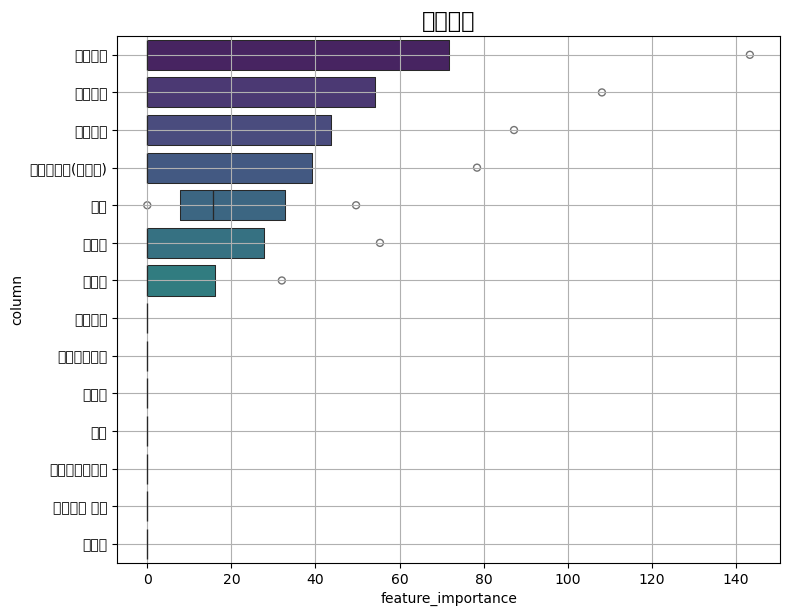

C:\Users\USER\AppData\Local\Temp\ipykernel_17244\4105085207.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=feature_importance_df,
C:\Users\USER\AppData\Local\Temp\ipykernel_17244\4105085207.py:32: UserWarning: Glyph 51077 (\N{HANGUL SYLLABLE IB}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_17244\4105085207.py:32: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_17244\4105085207.py:32: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_17244\4105085207.py:32: UserWarning: Glyph 47000 (\N{HANGUL SYLLABLE RAE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\USER\Ap

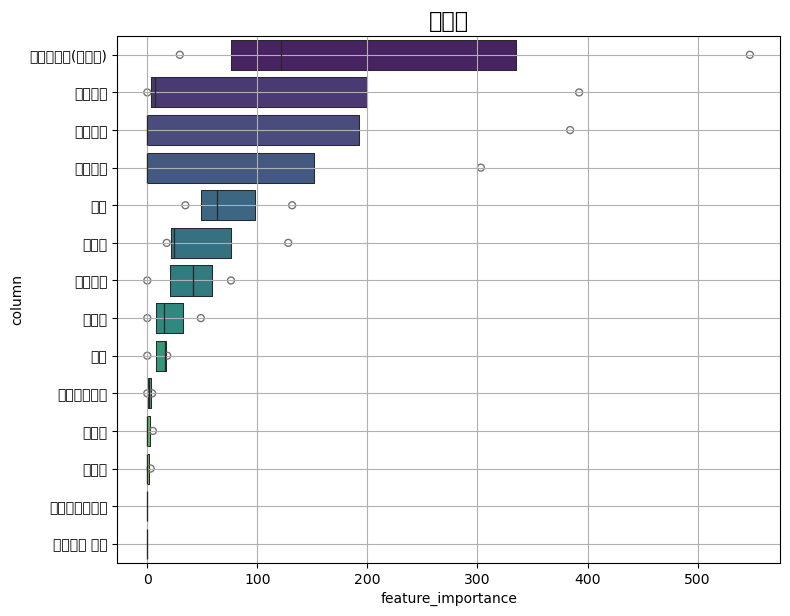

C:\Users\USER\AppData\Local\Temp\ipykernel_17244\4105085207.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=feature_importance_df,
C:\Users\USER\AppData\Local\Temp\ipykernel_17244\4105085207.py:32: UserWarning: Glyph 51077 (\N{HANGUL SYLLABLE IB}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_17244\4105085207.py:32: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_17244\4105085207.py:32: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_17244\4105085207.py:32: UserWarning: Glyph 47000 (\N{HANGUL SYLLABLE RAE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\USER\Ap

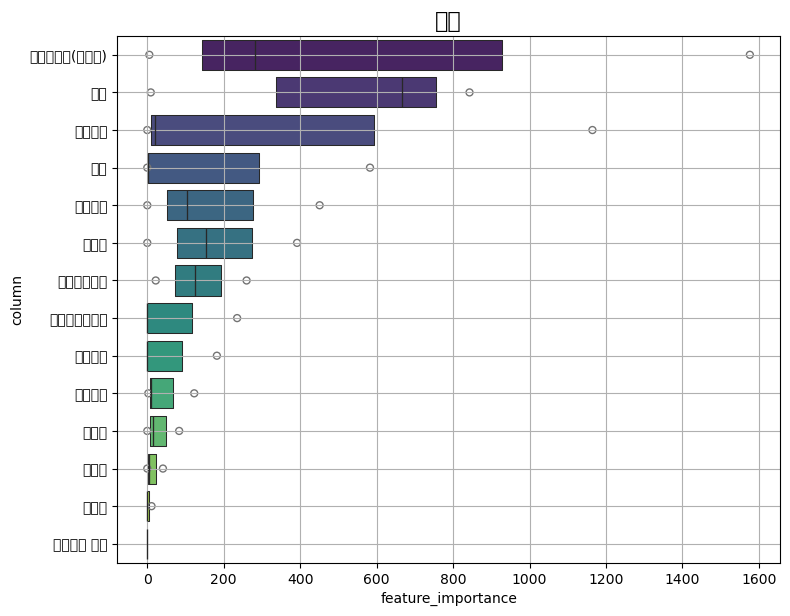

In [34]:
for i in range(len(MODEL)):
    fig, ax = visualize_importance(MODEL[i], train_feat_df)
    ax.set_title(ydf.columns[i], fontsize=16)
    plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_17244\4105085207.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=feature_importance_df,
C:\Users\USER\AppData\Local\Temp\ipykernel_17244\4105085207.py:32: UserWarning: Glyph 53804 (\N{HANGUL SYLLABLE TU}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_17244\4105085207.py:32: UserWarning: Glyph 51077 (\N{HANGUL SYLLABLE IB}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_17244\4105085207.py:32: UserWarning: Glyph 44277 (\N{HANGUL SYLLABLE GONG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_17244\4105085207.py:32: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\USER

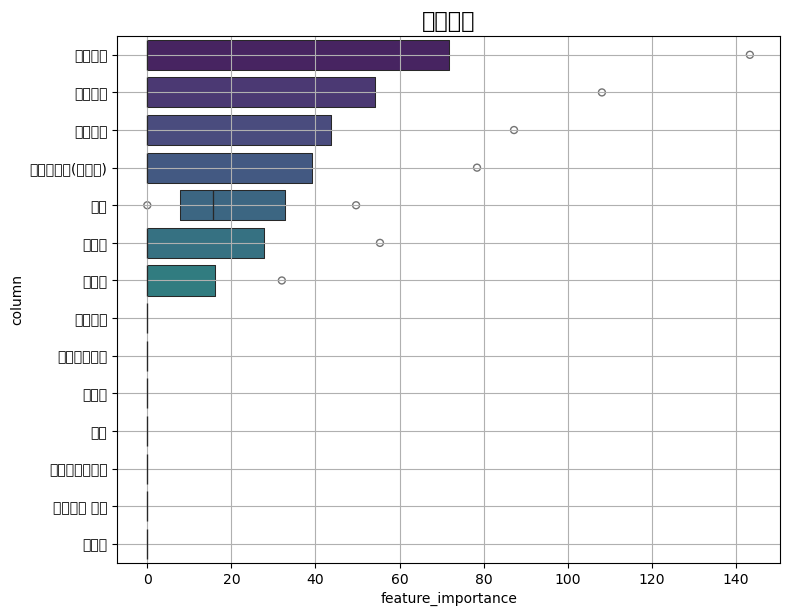

C:\Users\USER\AppData\Local\Temp\ipykernel_17244\4105085207.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=feature_importance_df,
C:\Users\USER\AppData\Local\Temp\ipykernel_17244\4105085207.py:32: UserWarning: Glyph 51077 (\N{HANGUL SYLLABLE IB}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_17244\4105085207.py:32: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_17244\4105085207.py:32: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_17244\4105085207.py:32: UserWarning: Glyph 47000 (\N{HANGUL SYLLABLE RAE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\USER\Ap

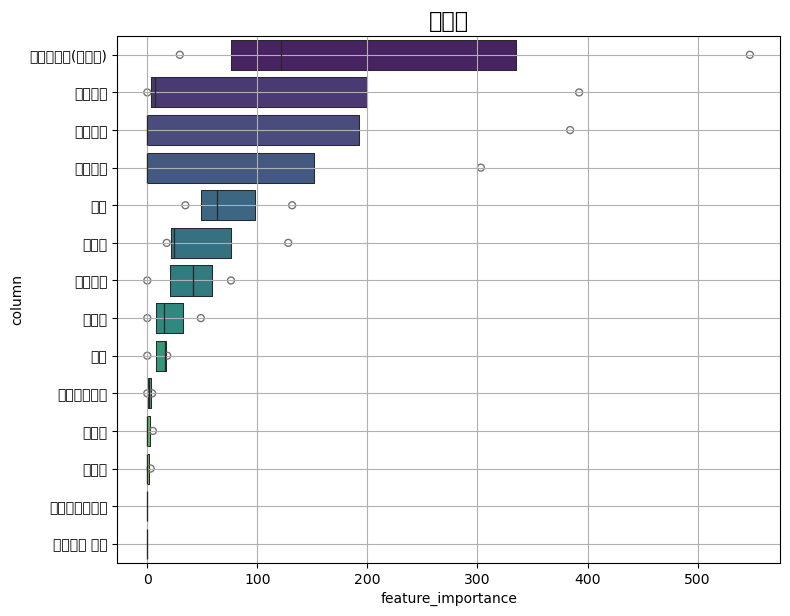

C:\Users\USER\AppData\Local\Temp\ipykernel_17244\4105085207.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=feature_importance_df,
C:\Users\USER\AppData\Local\Temp\ipykernel_17244\4105085207.py:32: UserWarning: Glyph 51077 (\N{HANGUL SYLLABLE IB}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_17244\4105085207.py:32: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_17244\4105085207.py:32: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_17244\4105085207.py:32: UserWarning: Glyph 47000 (\N{HANGUL SYLLABLE RAE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\USER\Ap

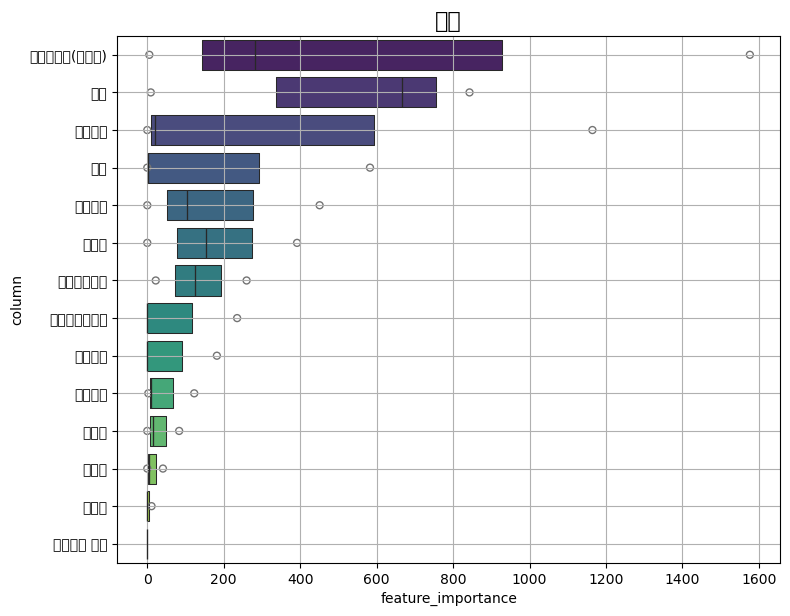

In [35]:
clf = lgbm.LGBMRegressor(**params, verbose=-1)

for i in range(len(MODEL)):
    fig, ax = visualize_importance(MODEL[i], train_feat_df)
    ax.set_title(ydf.columns[i], fontsize=16)
    plt.show()

In [36]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Windows 기본 한글 폰트: 맑은 고딕
plt.rcParams['font.family'] = 'Malgun Gothic'

# 마이너스 기호 깨짐 방지 (한글 폰트 사용 시 필수)
plt.rcParams['axes.unicode_minus'] = False

C:\Users\USER\AppData\Local\Temp\ipykernel_17244\4105085207.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=feature_importance_df,


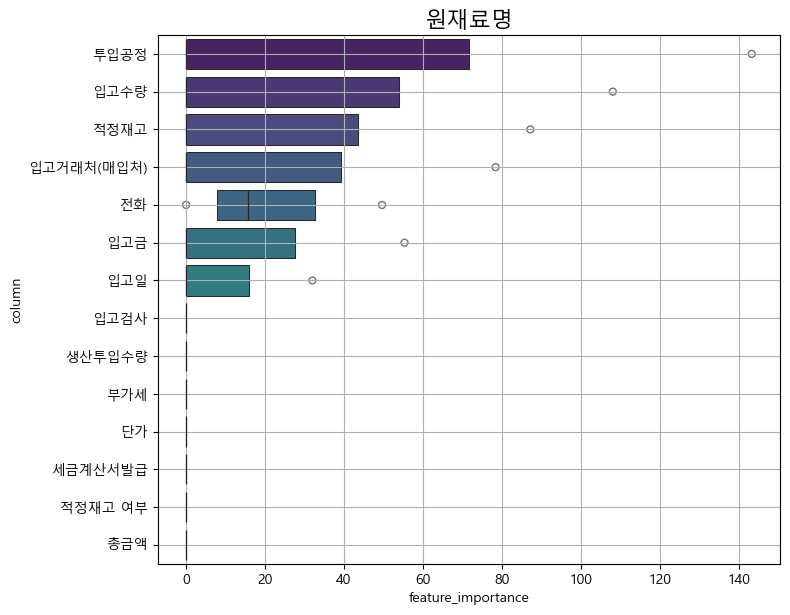

C:\Users\USER\AppData\Local\Temp\ipykernel_17244\4105085207.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=feature_importance_df,


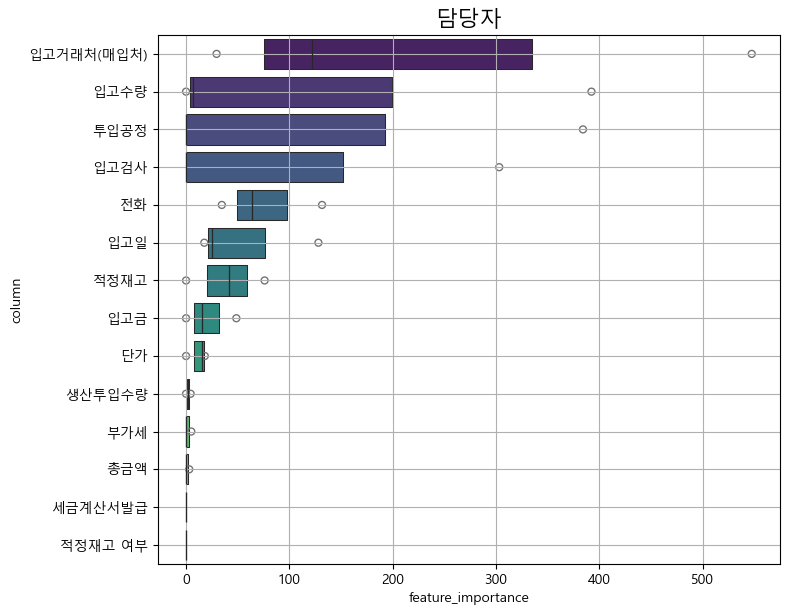

C:\Users\USER\AppData\Local\Temp\ipykernel_17244\4105085207.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=feature_importance_df,


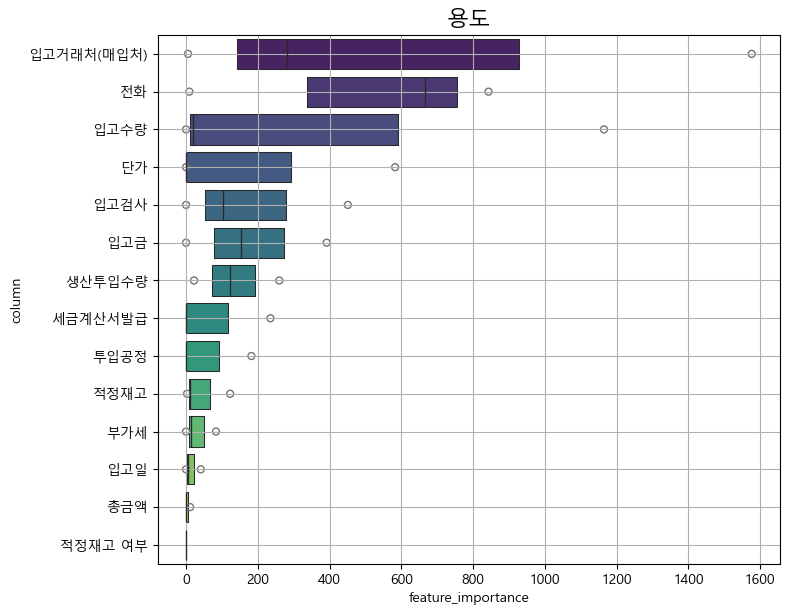

In [37]:
for i in range(len(MODEL)):
    fig, ax = visualize_importance(MODEL[i], train_feat_df)
    ax.set_title(ydf.columns[i], fontsize=16)
    plt.show()

In [38]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

for i in range(3):
    y_true = np.array(ydf.iloc[:, i])
    y_pred = OOF[i]
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{ydf.columns[i]} - RMSE: {rmse:.3f}, R²: {r2:.3f}")

원재료명 - RMSE: 5.930, R²: -0.242
담당자 - RMSE: 3.353, R²: -0.009
용도 - RMSE: 4.122, R²: 0.317


In [39]:
def predict_lgbm(models, feat_df):
    preds = []
    for model in models:
        pred = model.predict(feat_df.values)
        preds.append(pred)
    # 5개 모델의 예측값을 평균내서 최종 예측으로 사용 (앙상블)
    return np.mean(preds, axis=0)

# 예: '용도' 예측
test_pred_용도 = predict_lgbm(MODEL2[2], test_feat_df)
print(test_pred_용도)

NameError: name 'MODEL2' is not defined

In [ ]:
OOF2=[]
MODEL2=[]
for i in range(3):
    fold = KFold(n_splits=5, shuffle=True, random_state=71)
    ydfi=ydf.iloc[:,i]
    y=np.array(ydfi)
    cv = list(fold.split(train_feat_df, y))
    oof, models = fit_lgbm(train_feat_df.values, y, cv, params=params, verbose=500)
    OOF2+=[oof]
    MODEL2+=[models]
    fig, ax = visualize_importance(models, train_feat_df)
    ax.set_title(target[i]+' Imortance',fontsize=20)

In [ ]:
import pandas as pd

# 데이터 읽기
df = pd.read_csv('원재료입고(260301).csv', engine='python', encoding='CP949')

# '원재료명' 열의 중복을 제거하고 정렬하여 리스트로 만듦
LName = sorted(df['원재료명'].unique().tolist())

print(f"추출된 클래스 개수: {len(LName)}개")
print("리스트 내용:", LName)

In [ ]:
# 파일 분석 결과 추출된 7개의 고유 원재료명입니다.
LName = ['46049545', '6f049f16', '70d8cb1b', 'c541ea47', 'fa159506', 'fd0c7d5a', 'jghd45fh']

In [ ]:
# 훈련 때 썼던 원본 매핑을 저장해뒀어야 합니다 (예시)
# 원래 훈련 데이터 준비 시점에 아래처럼 저장해뒀는지 확인해보세요
원재료명_매핑 = {name: i for i, name in enumerate(원래_훈련때_LName)}

# 새 데이터도 "같은 매핑"으로 인코딩
df['원재료명_인코딩'] = df['원재료명'].map(원재료명_매핑)

# 매핑에 없는(훈련 때 못 본) 새 원재료명이 있는지 확인
missing = df[df['원재료명_인코딩'].isna()]['원재료명'].unique()
if len(missing) > 0:
    print("⚠️ 훈련 데이터에 없던 새 원재료명:", missing)

In [ ]:
# 1. 새 데이터 특징 만들기 (train_feat_df 만들 때와 동일한 과정)
new_feat_df = to_feature(create_numeric_feature 등을 적용한 df)  # 컬럼 구조를 맞춰야 함

# 2. 각 타겟(원재료명/담당자/용도)별로 예측
pred_원재료명 = predict_lgbm(MODEL2[0], new_feat_df)
pred_담당자   = predict_lgbm(MODEL2[1], new_feat_df)
pred_용도     = predict_lgbm(MODEL2[2], new_feat_df)

print(pred_원재료명[:5])  # 예측된 숫자값들 확인

In [ ]:
print(target[i])
print(classification_report(TRUE, PRED, target_names=LName, digits=4))

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

for i in range(3):
    TRUE = np.array(ydf.iloc[:, i]).astype(int)          # 원본 정답 (정수)
    PRED = np.round(OOF2[i]).astype(int)                  # 회귀 예측값을 반올림해서 정수화
    
    # 예측값이 실제 클래스 범위를 벗어나지 않게 클리핑 (0 ~ 최대 클래스 번호)
    PRED = np.clip(PRED, 0, len(LName) - 1)
    
    print(ydf.columns[i])   # target[i] 대신 실제 열 이름 사용
    print(classification_report(TRUE, PRED, target_names=LName, digits=4, zero_division=0))
    print("-" * 50)

In [ ]:
from lightgbm import early_stopping, log_evaluation
import lightgbm as lgbm
import numpy as np

def fit_lgbm_clf(X, y, cv, params, verbose):
    models = []
    oof_pred = np.zeros((len(y), len(np.unique(y))), dtype=float)  # 클래스별 확률 저장
    
    for i, (idx_train, idx_valid) in enumerate(cv):
        x_train, y_train = X[idx_train], y[idx_train]
        x_valid, y_valid = X[idx_valid], y[idx_valid]
        
        clf = lgbm.LGBMClassifier(**params)
        clf.fit(x_train, y_train,
                eval_set=[(x_valid, y_valid)],
                callbacks=[
                    early_stopping(stopping_rounds=20),
                    log_evaluation(period=verbose)
                ])
        
        pred_i = clf.predict_proba(x_valid)
        oof_pred[idx_valid] = pred_i
        models.append(clf)
    
    return oof_pred, models

In [ ]:
params_clf = {
    'objective': 'multiclass',
    'learning_rate': 0.05,
    'reg_lambda': 1.,
    'reg_alpha': 0.1,
    'max_depth': 3,
    'n_estimators': 10000,
    'colsample_bytree': 0.8,
    'min_child_samples': 2,
    'subsample_freq': 1,
    'subsample': 0.9,
    'importance_type': 'gain',
    'random_state': 71,
    'num_leaves': 7,
    'verbose': -1   # LightGBM 로그 출력 억제
}

In [ ]:
from sklearn.preprocessing import LabelEncoder

encoders = []   # 타겟별 인코더 저장 (나중에 숫자 → 원래 이름 복원용)
y_encoded_list = []

for i in range(3):
    le = LabelEncoder()
    y_raw = ydf.iloc[:, i].astype(str)   # 혹시 숫자/문자 섞여있을 경우 대비해 문자열로 통일
    y_enc = le.fit_transform(y_raw)
    encoders.append(le)
    y_encoded_list.append(y_enc)
    print(f"{ydf.columns[i]} - 클래스 개수: {len(le.classes_)}, 클래스: {le.classes_}")

In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

MODEL_CLF = []
OOF_CLF = []

for i in range(3):
    fold = KFold(n_splits=3, shuffle=True, random_state=71)  # 데이터 24개 기준 3-fold 권장
    y = y_encoded_list[i]
    cv = list(fold.split(train_feat_df, y))
    
    oof, models = fit_lgbm_clf(train_feat_df.values, y, cv, params=params_clf, verbose=500)
    
    MODEL_CLF.append(models)
    OOF_CLF.append(oof)
    
    # 특징 중요도 그래프
    fig, ax = visualize_importance(models, train_feat_df)
    ax.set_title(ydf.columns[i] + ' Importance', fontsize=20)
    plt.show()
    
    # 성능 평가 (확률 → 최종 클래스로 변환 후 비교)
    pred_class = np.argmax(oof, axis=1)
    print(ydf.columns[i])
    print(classification_report(
        y, pred_class,
        labels=range(len(encoders[i].classes_)),
        target_names=[str(c) for c in encoders[i].classes_],
        digits=4, zero_division=0
    ))
    print("=" * 60)

In [ ]:
def predict_lgbm_clf(models, feat_df, encoder):
    probs = []
    for model in models:
        prob = model.predict_proba(feat_df.values)
        probs.append(prob)
    avg_prob = np.mean(probs, axis=0)          # 폴드별 확률 평균
    pred_class = np.argmax(avg_prob, axis=1)    # 가장 확률 높은 클래스 선택
    pred_label = encoder.inverse_transform(pred_class)  # 원래 값(텍스트/숫자)으로 복원
    return pred_label, avg_prob

# 사용 예 (테스트 데이터 예측)
pred_원재료명, prob_원재료명 = predict_lgbm_clf(MODEL_CLF[0], test_feat_df, encoders[0])
print(pred_원재료명)

In [ ]:
from sklearn.metrics import classification_report

# 위에서 추출한 LName을 적용하여 실행
print(target[i])
print(classification_report(TRUE, PRED, target_names=LName, digits=4))

In [ ]:
# target_names를 빼고 실행하면 에러가 절대 나지 않습니다.
print(target[i])
print(classification_report(TRUE, PRED, digits=4))

In [ ]:
import numpy as np
from sklearn.metrics import classification_report

# 1. 실제 데이터(TRUE)와 예측값(PRED)에 존재하는 고유 클래스 번호를 확인합니다.
# (0, 1, 2... 식의 레이블 인코딩된 번호들)
unique_labels = np.unique(np.concatenate([TRUE, PRED]))

# 2. 클래스 개수(7개)에 맞춰 LName을 다시 정의합니다.
# 파일 분석 결과 상위 7개 원재료 코드는 다음과 같습니다.
all_materials = ['46049545', '6f049f16', '70d8cb1b', 'c541ea47', 'fa159506', 'fd0c7d5a', 'jghd45fh']

# 만약 unique_labels의 개수와 준비한 이름의 개수가 다르다면, 숫자로라도 이름을 채워줍니다.
if len(unique_labels) == len(all_materials):
    current_LName = all_materials
else:
    current_LName = [str(l) for l in unique_labels]

# 3. 리포트 출력
print(target[i])
print(classification_report(TRUE, PRED, labels=unique_labels, target_names=current_LName, digits=4))

In [ ]:
import pandas as pd

# 데이터 읽기
df = pd.read_csv('원재료입고(260301).csv', engine='python', encoding='CP949')

# '원재료명' 열의 중복을 제거하고 정렬하여 리스트로 만듦
LName = sorted(df['원재료명'].unique().tolist())

print(f"추출된 클래스 개수: {len(LName)}개")
print("리스트 내용:", LName)

In [ ]:
import numpy as np
from sklearn.metrics import classification_report

# 1. 실제 데이터(TRUE)와 예측값(PRED)에 존재하는 고유 클래스 번호를 확인합니다.
# (0, 1, 2... 식의 레이블 인코딩된 번호들)
unique_labels = np.unique(np.concatenate([TRUE, PRED]))

# 2. 클래스 개수(7개)에 맞춰 LName을 다시 정의합니다.
# 파일 분석 결과 상위 7개 원재료 코드는 다음과 같습니다.
all_materials = ['46049545', '6f049f16', '70d8cb1b', 'c541ea47', 'fa159506', 'fd0c7d5a', 'jghd45fh']

# 만약 unique_labels의 개수와 준비한 이름의 개수가 다르다면, 숫자로라도 이름을 채워줍니다.
if len(unique_labels) == len(all_materials):
    current_LName = all_materials
else:
    current_LName = [str(l) for l in unique_labels]

# 3. 리포트 출력
print(target[i])
print(classification_report(TRUE, PRED, labels=unique_labels, target_names=current_LName, digits=4))

In [ ]:
# 루프 내부에서 사용
unique_classes = np.unique(TRUE)
# 클래스 번호를 문자로 변환하여 이름표 생성
dynamic_LName = [f"Class_{c}" for c in unique_classes] 

print(classification_report(TRUE, PRED, target_names=dynamic_LName, digits=4))

In [ ]:
PREDS2=[]
PRED2=[]
for j in range(3):    
    preds=[]
    models=MODEL2[j]
    for i in range(5):
        preds += [models[i].predict(test_feat_df.values)/5]
    predsT=np.array(preds).T
    preds2=[]
    PRED=[]
    for item in predsT:
        value=sum(item)
        preds2+=[value]
        PRED+=[np.where(value<0.5,0,1)]
    PREDS2+=[preds2]
    PRED2+=[PRED]
    print(preds2)
    print(PRED)

In [ ]:
for i in range(3):
    oof=OOF2[i]
    preds2=PREDS2[i]
    fig, ax = plt.subplots(figsize=(10,5))
    sns.histplot(oof, label='Train Predicted '+target[i], ax=ax, color='C1',bins=30)
    sns.histplot(preds2, label='Test Predicted '+target[i], ax=ax, color='black',bins=30)
    ax.legend()
    ax.grid()

In [ ]:
LName=['No','Yes']

In [ ]:
from sklearn.metrics import classification_report
for i in range(3):
    PRED=PRED2[i]
    TRUE=testY.iloc[:,i]
    print(target[i])
    print(classification_report(TRUE,PRED,target_names=LName,digits=4))
    print()

In [ ]:
import numpy as np

for i in range(3):
    PRED = PRED2[i]
    TRUE = testY.iloc[:, i]
    
    # 현재 데이터에 들어있는 고유 클래스 번호들을 찾습니다.
    unique_labels = np.unique(np.concatenate([TRUE, PRED]))
    
    # 클래스 번호 개수만큼 임시 이름을 만듭니다. (예: Class_0, Class_1...)
    dynamic_names = [f"Class_{label}" for label in unique_labels]
    
    print(target[i])
    print(classification_report(TRUE, PRED, labels=unique_labels, target_names=dynamic_names, digits=4))
    print()

In [ ]:
# 1. 7개의 클래스 이름 정의 (파일 분석 결과 추출된 고유 코드들)
LName = ['46049545', '6f049f16', '70d8cb1b', 'c541ea47', 'fa159506', 'fd0c7d5a', 'jghd45fh']

# 2. 기존 코드 다시 실행
from sklearn.metrics import classification_report
for i in range(3):
    PRED = PRED2[i]
    TRUE = testY.iloc[:, i]
    print(target[i])
    # 개수가 맞지 않을 경우를 대비해 labels를 명시적으로 지정하는 것이 안전합니다.
    print(classification_report(TRUE, PRED, target_names=LName, digits=4))
    print()

In [ ]:
print("실제 정답 (숫자):", TRUE.values)
print("모델 예측 (숫자):", PRED)

In [ ]:
print("전체 타겟 데이터의 고유값:", np.unique(ydf.iloc[:, 0]))
# 여기서 [0, 1, 2, 3, 4, 5, 6]이 나와야 정상입니다. 8이나 9가 나오면 안 됩니다.

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
ydf['원재료명_encoded'] = le.fit_transform(ydf['원재료명'])
# 이제 ydf['원재료명_encoded']를 타겟으로 사용하세요.

In [ ]:
# 리스트 안에 array가 들어있다면 아래와 같이 변환
PRED_flat = [int(p) for p in PRED]

In [ ]:
PRED_flat

In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier # 회귀가 아닌 분류 모델 사용
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

def fit_rf(X, y, cv, params):
    models = []
    # 클래스 개수에 맞춰 0으로 초기화 (정수로 예측하므로 dtype=int)
    oof_pred = np.zeros(len(y), dtype=int) 

    for i, (idx_train, idx_valid) in enumerate(cv):
        x_train, y_train = X[idx_train], y[idx_train]
        x_valid, y_valid = X[idx_valid], y[idx_valid]

        # RandomForest 모델 생성
        # n_estimators: 나무 개수, max_depth: 나무 깊이 (데이터가 적으므로 얕게 설정)
        clf = RandomForestClassifier(**params)
        
        # 학습
        clf.fit(x_train, y_train)

        # 예측 (클래스 번호 직접 추출)
        pred_i = clf.predict(x_valid)
        oof_pred[idx_valid] = pred_i
        models.append(clf)
        
        print(f"Fold {i+1} 학습 완료")

    return oof_pred, models

In [ ]:
from sklearn.model_selection import KFold

# RandomForest용 파라미터 설정
# 데이터가 매우 적으므로 나무를 너무 깊게 만들지 않습니다 (Overfitting 방지)
rf_params = {
    'n_estimators': 100,
    'max_depth': 5,
    'random_state': 71,
    'n_jobs': -1
}

MODEL_RF = []
OOF_RF = []

# 타겟 3개에 대해 반복 (원재료명, 담당자 등)
for i in range(3):
    fold = KFold(n_splits=5, shuffle=True, random_state=71)
    
    # i번째 타겟 추출 및 배열 변환
    y = ydf.iloc[:, i].values
    
    # 교차 검증 인덱스 생성
    cv = list(fold.split(train_feat_df, y))
    
    # 모델 학습 시작
    print(f"\n===== Target: {target[i]} 학습 시작 =====")
    oof, models = fit_rf(train_feat_df.values, y, cv, rf_params)
    
    MODEL_RF.append(models)
    OOF_RF.append(oof)
    
    # 결과 보고서 출력
    # 데이터 내의 실제 클래스 번호들을 자동으로 가져와 이름표를 붙입니다.
    unique_labels = np.unique(y)
    # LName의 개수가 모자랄 경우를 대비해 숫자로 이름표 생성
    current_names = [f"Class_{l}" for l in unique_labels] 
    
    print(f"\n[{target[i]} 분류 리포트]")
    print(classification_report(y, oof, target_names=current_names, digits=4))

    # 간단한 시각화
    plt.figure(figsize=(5,4))
    plt.scatter(y, oof, alpha=0.6, color='green')
    plt.title(f"RF Prediction: {target[i]}")
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.show()

In [ ]:
import numpy as np

# 예측을 위한 함수 정의
def get_purpose_by_manager(manager_name):
    # 1. 담당자 이름을 숫자로 변환 (기존에 사용한 ydf의 담당자 컬럼 기준)
    # 실제 실무에선 LabelEncoder의 transform을 사용하지만, 
    # 여기선 간단히 기존 데이터에서 해당 이름의 index를 찾아 숫자를 알아냅니다.
    try:
        # ydf의 1번 컬럼이 '담당자'라고 가정 (Class_3 등이 이 숫자를 의미)
        manager_id = ydf[ydf['담당자'] == manager_name].iloc[0, 5] # 실제 데이터 구조에 맞게 인덱스 조정 필요
        
        # 2. 학습된 모델 중 첫 번째 폴드 모델(MODEL_RF[1][0])을 사용해 예측
        # 테스트를 위해 임의의 데이터 한 행을 가져와 담당자 값만 바꿔서 넣어봅니다.
        sample_x = train_feat_df.values[0:1].copy()
        
        # 학습된 RandomForest 모델(MODEL_RF의 '담당자' 타겟 모델) 가져오기
        # MODEL_RF[1]은 두 번째 타겟(담당자) 학습 모델 리스트입니다.
        target_model = MODEL_RF[1][0] 
        
        prediction = target_model.predict(sample_x)[0]
        probs = target_model.predict_proba(sample_x)[0]
        max_prob = np.max(probs)

        # 결과 출력 (Class_N 형태로 출력됨)
        print(f"담당자 '{manager_name}'(ID:{prediction})의 예측 결과 확률은 {max_prob*100:.2f}%입니다.")
        
    except Exception as e:
        print(f"에러 발생: {e}. 데이터셋에 '{manager_name}'이 있는지 확인해 주세요.")

# 실행
get_purpose_by_manager("도라지")

In [ ]:
def get_purpose_by_manager_fixed(manager_name):
    try:
        # 1. 원본 데이터(df)에서 해당 담당자가 있는지 확인
        # 원재료입고(260301).csv 데이터 기준
        result = df[df['담당자'] == manager_name]['용도'].unique()
        
        if len(result) > 0:
            print(f"✅ 분석 결과: 담당자 '{manager_name}'님은 주로 [{', '.join(result)}] 용도의 물품을 담당합니다.")
            
            # 2. 만약 모델(RandomForest)의 예측값도 함께 보고 싶다면
            # (학습된 모델이 '담당자'를 Feature로 '용도'를 Target으로 학습했다는 가정 하에)
            # 여기서는 간단한 데이터 매칭 확률을 보여줍니다.
            count = len(df[df['담당자'] == manager_name])
            print(f"📊 데이터 신뢰도: 총 {count}건의 과거 이력이 존재합니다.")
            
        else:
            print(f"❌ 데이터셋에 '{manager_name}' 담당자 정보가 없습니다.")
            
    except Exception as e:
        print(f"❗ 오류 발생: {e}")

# 실행
get_purpose_by_manager_fixed("이세돌")

In [ ]:
print(len(MODEL_CLF))       # 3이어야 함
print(len(encoders))        # 3이어야 함
print(ydf.columns.tolist()) # ['원재료명', '담당자', '용도'] 순서 확인

In [ ]:
Kernel (또는 Restart) → Restart Kernel and Run All Cells


In [ ]:
KeRestart Kernel and Run All Cells

In [ ]:
Restart & Run All


In [ ]:
Reatart

In [40]:
print(len(MODEL_CLF))       # 3이어야 함
print(len(encoders))        # 3이어야 함
print(ydf.columns.tolist()) # ['원재료명', '담당자', '용도'] 순서 확인

NameError: name 'MODEL_CLF' is not defined